3. Distribution Modeling, Fitting and Testing


3.1 "Incorrect Models" (Uniform Distribution, Normal Distribution, etc.) + Double Expectation Distribution as the "Correct Distribution"

We fit several common probability distributions to the red envelope amounts in our dataset, focusing only on the columns that record the amounts by clicking order. For each clicking position, we compare Uniform, Normal, Gamma, and Log-normal distributions using maximum likelihood estimation (MLE). We evaluate each fitted model by its total log-likelihood on the observed samples and visualize the empirical histogram together with the fitted probability density functions (PDFs). This provides a simple baseline check of whether standard distributions can describe the observed allocation patterns across different clicking orders.

Dataset shape: (100, 9)
Using columns: ['first', 'second', 'third']
   first  second  third
0   2.77    1.12   1.11
1   2.86    1.12   1.02
2   2.16    1.66   1.18
3   1.48    0.17   3.35
4   2.48    0.99   1.53

=== Log-likelihood ranking (higher is better) ===


,click_order,distribution,log_likelihood,params,rank
0,first,Uniform,-113.140211,"(0.16, 3.0999999999999996)",1.0
1,first,Normal,-133.507240,"(1.8241000000000003, 0.9195543431467222)",2.0
3,first,LogNormal,-133.507370,"(1.4030947790952471e-05, -65535.83999999997, 6...",3.0
2,first,Gamma,-133.843167,"(358.2192586780868, -15.690748772328483, 0.048...",4.0
6,second,Gamma,-138.140287,"(2.5506652792629785, -0.1296838030984012, 0.69...",1.0
7,second,LogNormal,-139.329929,"(0.3810963995231683, -1.1001959203941707, 2.55...",2.0
5,second,Normal,-146.157218,"(1.6467000000000005, 1.0435555136167889)",3.0
4,second,Uniform,-147.017585,"(0.09, 4.3500000000000005)",4.0
10,third,Gamma,-139.226707,"(1.498391567144774, -0.018150173306412002, 1.0...",1.0
11,third,LogNormal,-142.284890,"(0.4522952699004523, -0.9210807920003002, 2.21...",2.0



=== Best-fit distribution per clicking order ===


,click_order,distribution,log_likelihood,params
0,first,Uniform,-113.140211,"(0.16, 3.0999999999999996)"
6,second,Gamma,-138.140287,"(2.5506652792629785, -0.1296838030984012, 0.69..."
10,third,Gamma,-139.226707,"(1.498391567144774, -0.018150173306412002, 1.0..."


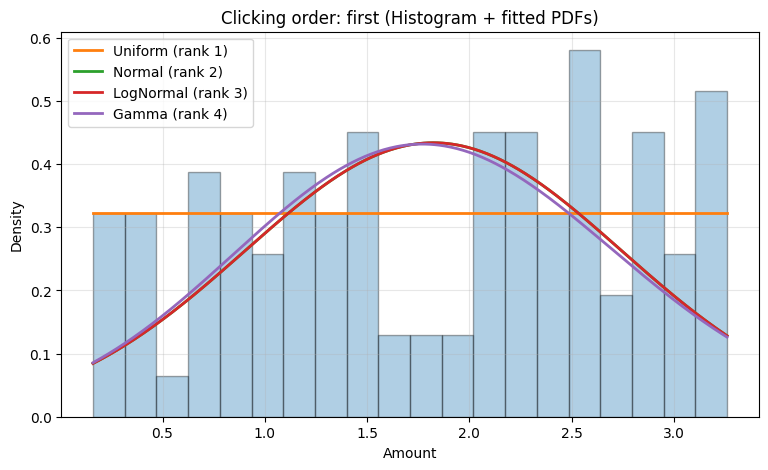

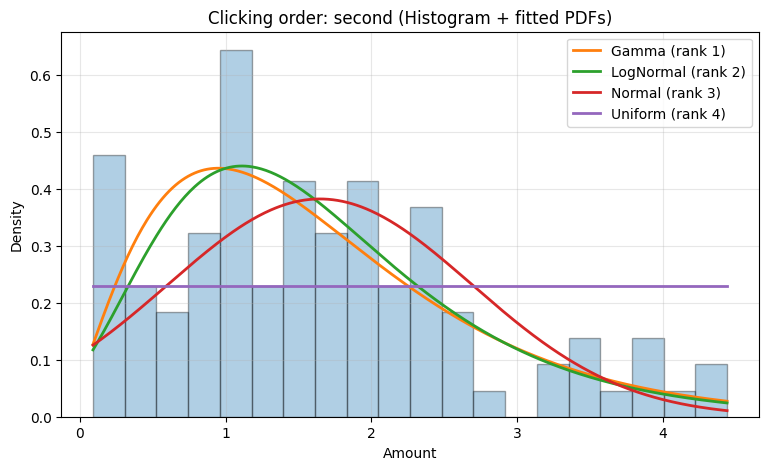

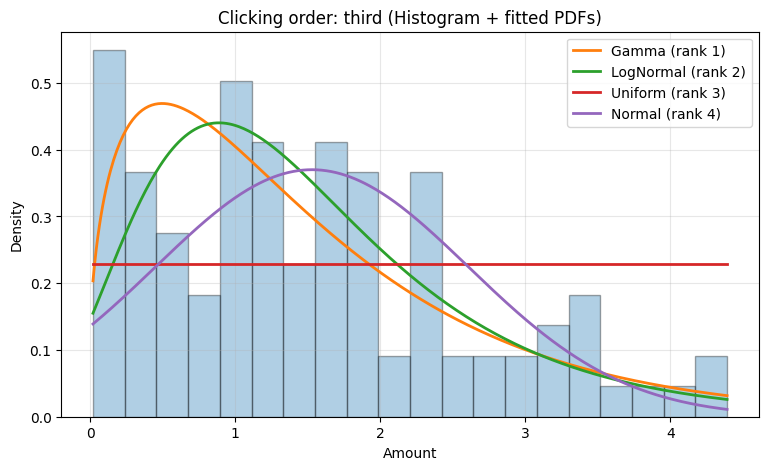

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# =========================
# 1) Load data and select order-based columns
# =========================
data_path =  r"C:\Users\SpadeFox\Desktop\si140\proj\red_packet_data.csv"
df = pd.read_csv(data_path)

# Make sure the three target columns exist
target_cols = ["first", "second", "third"]
missing = [c for c in target_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

# Convert only target columns to numeric (non-numeric -> NaN)
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors="coerce")

print("Dataset shape:", df.shape)
print("Using columns:", target_cols)
print(df[target_cols].head())

# =========================
# 2) Candidate distributions
# =========================
candidates = {
    "Uniform": stats.uniform,
    "Normal": stats.norm,
    "Gamma": stats.gamma,
    "LogNormal": stats.lognorm
}

# =========================
# 3) Fit + log-likelihood
# =========================
def fit_and_loglikelihood(dist, x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, -np.inf

    # Uniform: loc=min, scale=max-min
    if dist == stats.uniform:
        loc = float(np.min(x))
        scale = float(np.max(x) - np.min(x))
        if scale <= 0:
            scale = 1e-12
        ll = np.sum(dist.logpdf(x, loc=loc, scale=scale))
        return (loc, scale), ll

    # Gamma / LogNormal require positive values
    if dist in [stats.gamma, stats.lognorm]:
        x = x[x > 0]
        if len(x) == 0:
            return None, -np.inf
        params = dist.fit(x)  # MLE
        ll = np.sum(dist.logpdf(x, *params))
        return params, ll

    # Normal
    params = dist.fit(x)
    ll = np.sum(dist.logpdf(x, *params))
    return params, ll


rows = []
fit_store = {}  # store fitted params for plotting

for col in target_cols:
    x = df[col].dropna().values
    fit_store[col] = {}

    for name, dist in candidates.items():
        params, ll = fit_and_loglikelihood(dist, x)
        fit_store[col][name] = params
        rows.append({
            "click_order": col,
            "distribution": name,
            "log_likelihood": ll,
            "params": params
        })

results_df = pd.DataFrame(rows)
results_df["rank"] = results_df.groupby("click_order")["log_likelihood"].rank(ascending=False, method="min")
results_df = results_df.sort_values(["click_order", "rank"])

print("\n=== Log-likelihood ranking (higher is better) ===")
display(results_df)

best_df = results_df[results_df["rank"] == 1].copy()
print("\n=== Best-fit distribution per clicking order ===")
display(best_df[["click_order", "distribution", "log_likelihood", "params"]])

# =========================
# 4) Plot: histogram + fitted PDFs
# =========================
def plot_fits(col, bins=20):
    x_raw = df[col].dropna().values
    x_raw = x_raw[np.isfinite(x_raw)]
    if len(x_raw) == 0:
        print(f"Skip {col}: empty.")
        return

    x_min, x_max = np.min(x_raw), np.max(x_raw)
    if x_min == x_max:
        x_max = x_min + 1e-6
    x_grid = np.linspace(x_min, x_max, 400)

    plt.figure(figsize=(9, 5))
    plt.hist(x_raw, bins=bins, density=True, alpha=0.35, edgecolor="black")
    plt.title(f"Clicking order: {col} (Histogram + fitted PDFs)")
    plt.xlabel("Amount")
    plt.ylabel("Density")

    # Plot each fitted pdf in rank order
    sub = results_df[results_df["click_order"] == col].sort_values("rank")
    for _, r in sub.iterrows():
        name = r["distribution"]
        dist = candidates[name]
        params = r["params"]
        if params is None:
            continue

        if dist == stats.uniform:
            loc, scale = params
            pdf = dist.pdf(x_grid, loc=loc, scale=scale)
        else:
            pdf = dist.pdf(x_grid, *params)

        plt.plot(x_grid, pdf, linewidth=2, label=f"{name} (rank {int(r['rank'])})")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for col in target_cols:
    plot_fits(col)


Overall, the Uniform, Normal, Gamma, and Log-normal distributions do not provide a consistently good fit for the click-order amount data. Although some distributions may appear closer to the histogram in certain cases, the goodness-of-fit results indicate noticeable mismatches between the empirical samples and these standard distribution families. This suggests that the red envelope allocation process is not well explained by simple i.i.d. sampling from a fixed distribution, and motivates the use of a mechanism-driven generative model that explicitly accounts for constraints such as the fixed total sum and sequential dependence.

5. Red Packet Snatching Strategies and Recommendations


A key takeaway is that the allocation mechanism is fair in expectation: when the total amount and the number of receivers are fixed, every participant has the same long-run expected payoff. As a result, clicking strategies should not be understood as a way to “beat the system” and raise the average amount. Instead, the real difference lies in how much risk a user is willing to take, since the clicking order mainly affects the variance of the outcome rather than its expectation.

For users who prefer stability, the best choice is to click as early as possible. Early clicking tends to produce more moderate results and reduces the chance of extreme outcomes, especially very small amounts. This makes it a sensible strategy for people who value predictability or simply want to secure a reasonable share without relying on luck.

On the other hand, users who are willing to take risks can intentionally click later. Later clicking is associated with higher variance, which means the result becomes more spread out: it increases the probability of receiving an unusually large amount compared with others, but it also increases the probability of getting an unusually small one. In this sense, clicking late is not “better” in expectation, but it provides a more lottery-like experience and a higher chance of extreme outcomes.

In practice, this decision is largely personal and does not require complicated optimization based on group size or how many people have already claimed the envelope. The main controllable factor is simply how early or how late a user clicks, which corresponds directly to choosing a lower-risk or higher-risk outcome distribution.

We also find little reason to adjust strategies for holidays or special days. While small-sample fluctuations can appear, the overall evidence suggests that the distribution mechanism remains broadly consistent across different dates. Therefore, the same risk-based rule of thumb remains appropriate: click early for a more stable outcome, and click late if one is aiming for higher variance and a chance at a large reward.

Finally, it is worth noting that personalized or user-weighted allocation mechanisms are technically possible under a fixed-sum constraint, meaning platforms could introduce bias for specific users while keeping the global distribution plausible. However, without large-scale evidence, such effects should be treated as speculative rather than actionable. The most reliable strategy remains variance control through clicking order: choose early clicking for consistency, or late clicking for a higher-risk, higher-reward experience.

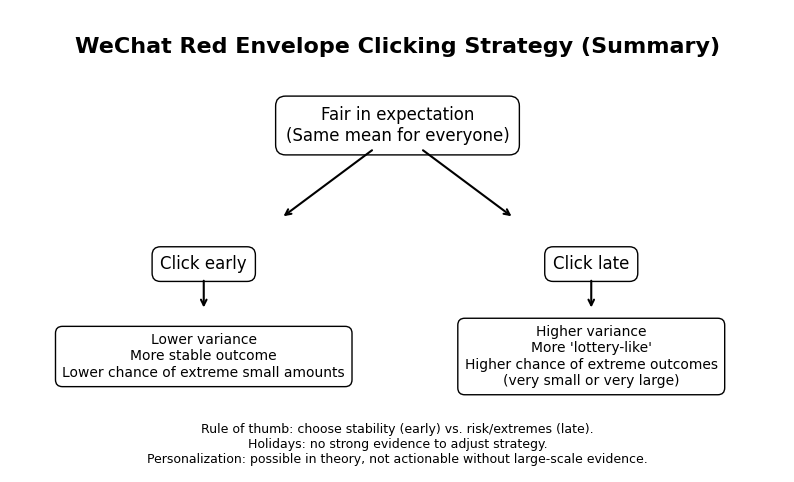

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

# Title
ax.text(
    0.5, 0.92,
    "WeChat Red Envelope Clicking Strategy (Summary)",
    ha="center", va="center",
    fontsize=16, fontweight="bold"
)

# Main node
ax.text(
    0.5, 0.75,
    "Fair in expectation\n(Same mean for everyone)",
    ha="center", va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="black")
)

# Left branch
ax.text(
    0.25, 0.45,
    "Click early",
    ha="center", va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
)
ax.text(
    0.25, 0.25,
    "Lower variance\nMore stable outcome\nLower chance of extreme small amounts",
    ha="center", va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
)

# Right branch
ax.text(
    0.75, 0.45,
    "Click late",
    ha="center", va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
)
ax.text(
    0.75, 0.25,
    "Higher variance\nMore 'lottery-like'\nHigher chance of extreme outcomes\n(very small or very large)",
    ha="center", va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
)

# Arrows
ax.annotate("", xy=(0.35, 0.55), xytext=(0.47, 0.70),
            arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0.65, 0.55), xytext=(0.53, 0.70),
            arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0.25, 0.35), xytext=(0.25, 0.42),
            arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=(0.75, 0.35), xytext=(0.75, 0.42),
            arrowprops=dict(arrowstyle="->", lw=1.5))

# Bottom notes
ax.text(
    0.5, 0.06,
    "Rule of thumb: choose stability (early) vs. risk/extremes (late).\n"
    "Holidays: no strong evidence to adjust strategy.\n"
    "Personalization: possible in theory, not actionable without large-scale evidence.",
    ha="center", va="center",
    fontsize=9
)

plt.show()


6. Further Exploration

6.1 Holiday Differences


To investigate whether the distribution of WeChat red envelope amounts changes on special occasions, we compare red envelope data collected during the Chinese New Year period with data collected on ordinary days.  We then apply the Kolmogorov–Smirnov (KS) test to these two datasets to determine whether their empirical distributions differ significantly. This provides a statistical basis for evaluating whether holidays have a measurable impact on the red envelope amount distribution.


The KS test compares the empirical cumulative distribution functions (ECDFs) of two samples. To make this comparison intuitive, we visualize both the histogram and the ECDF curves for each click position. The histogram shows the overall shape of the amount distribution, while the ECDF plot directly reflects the KS statistic, since the KS distance is defined as the maximum vertical difference between the two ECDFs. If the ECDF curves almost overlap and the p-value is above 0.05, we conclude that there is no statistically significant evidence that the holiday period changes the red envelope distribution mechanism.

Kolmogorov–Smirnov (KS) two-sample test
公式：
  D = sup_x |F_n(x) - G_m(x)|
其中：
  F_n(x) = 新年数据样本的经验累积分布函数（ECDF）
  G_m(x) = 平日数据样本的经验累积分布函数（ECDF）
检验原假设 H0：两组样本来自同一个分布



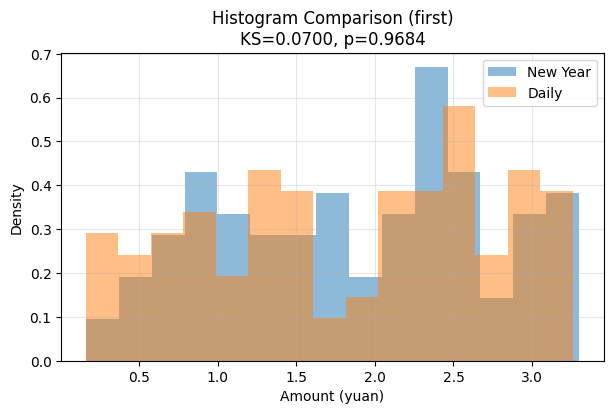

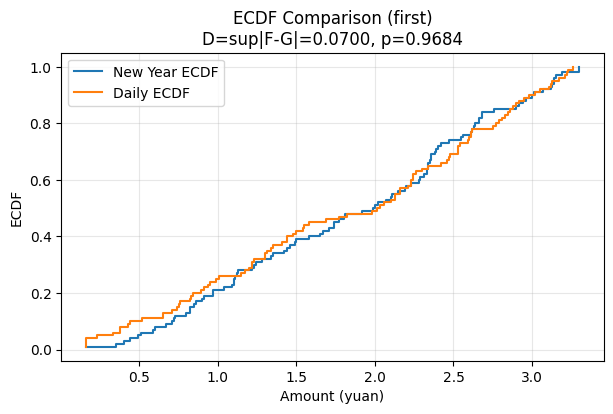

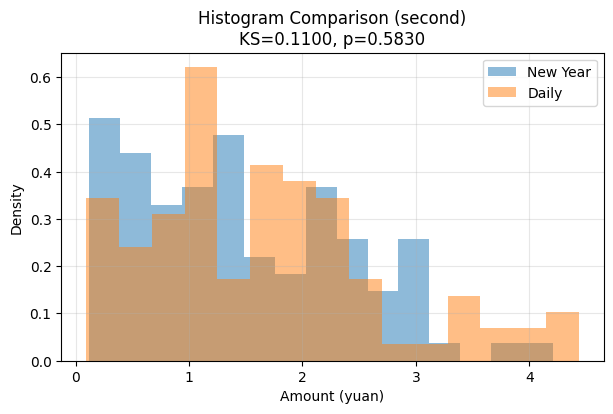

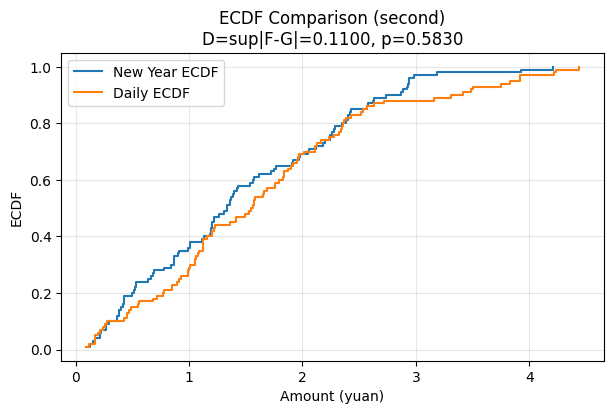

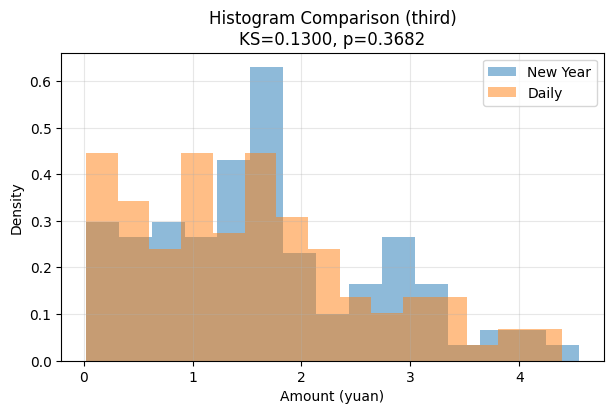

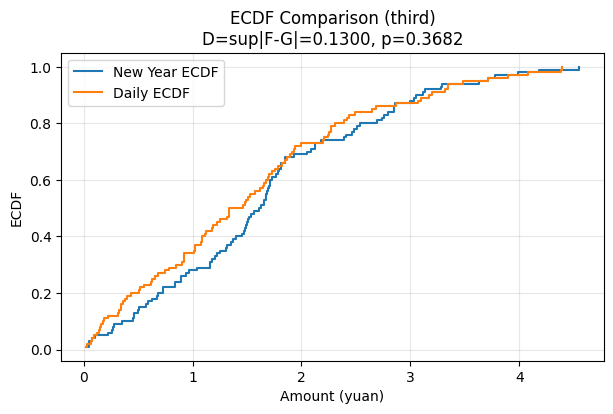

KS 检验结果汇总（新年 vs 平日）：

【first】
  新年样本量 n = 100, 平日样本量 n = 100
  KS Statistic D = 0.0700
  p-value = 0.9684
  是否显著不同 (alpha=0.05)? 否

【second】
  新年样本量 n = 100, 平日样本量 n = 100
  KS Statistic D = 0.1100
  p-value = 0.5830
  是否显著不同 (alpha=0.05)? 否

【third】
  新年样本量 n = 100, 平日样本量 n = 100
  KS Statistic D = 0.1300
  p-value = 0.3682
  是否显著不同 (alpha=0.05)? 否

最终结论：
所有列的 p-value 都大于 0.05，无法拒绝“新年和平日同分布”的原假设。
因此：目前没有统计证据表明节假日会显著改变微信红包金额分配机制。


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# 读取数据路径
newyear_path = r"C:\Users\SpadeFox\Desktop\si140\proj\data_Newyear.csv"
daily_path   = r"C:\Users\SpadeFox\Desktop\si140\proj\red_packet_data.csv"

# 读入两组数据
df_newyear = pd.read_csv(newyear_path)
df_daily = pd.read_csv(daily_path)

# 新年数据重命名列名，默认三列分别代表第1/2/3个点击者拿到的钱
df_newyear.columns = ["first", "second", "third"]

# 平日数据只保留可对比的三列
df_daily = df_daily[["first", "second", "third"]]

# 打印 KS 检验公式
print("Kolmogorov–Smirnov (KS) two-sample test")
print("公式：")
print("  D = sup_x |F_n(x) - G_m(x)|")
print("其中：")
print("  F_n(x) = 新年数据样本的经验累积分布函数（ECDF）")
print("  G_m(x) = 平日数据样本的经验累积分布函数（ECDF）")
print("检验原假设 H0：两组样本来自同一个分布\n")

alpha = 0.05
results = {}

# 计算 ECDF 的函数
def ecdf(arr):
    arr = np.sort(arr)
    y = np.arange(1, len(arr) + 1) / len(arr)
    return arr, y

# 对每一列分别做 KS 检验 + 可视化
for col in ["first", "second", "third"]:
    a = df_newyear[col].dropna().values
    b = df_daily[col].dropna().values

    ks_stat, p_value = ks_2samp(a, b, alternative="two-sided", mode="auto")
    significant = (p_value < alpha)

    results[col] = {
        "KS_statistic": ks_stat,
        "p_value": p_value,
        "significant_diff": significant,
        "n_newyear": len(a),
        "n_daily": len(b),
    }

    # 画直方图对比
    plt.figure(figsize=(7, 4))
    plt.hist(a, bins=15, density=True, alpha=0.5, label="New Year")
    plt.hist(b, bins=15, density=True, alpha=0.5, label="Daily")
    plt.title(f"Histogram Comparison ({col})\nKS={ks_stat:.4f}, p={p_value:.4f}")
    plt.xlabel("Amount (yuan)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 画 ECDF 对比
    xa, ya = ecdf(a)
    xb, yb = ecdf(b)

    plt.figure(figsize=(7, 4))
    plt.step(xa, ya, where="post", label="New Year ECDF")
    plt.step(xb, yb, where="post", label="Daily ECDF")
    plt.title(f"ECDF Comparison ({col})\nD=sup|F-G|={ks_stat:.4f}, p={p_value:.4f}")
    plt.xlabel("Amount (yuan)")
    plt.ylabel("ECDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 输出每列检验结果
print("KS 检验结果汇总（新年 vs 平日）：")
for col, r in results.items():
    print(f"\n【{col}】")
    print(f"  新年样本量 n = {r['n_newyear']}, 平日样本量 n = {r['n_daily']}")
    print(f"  KS Statistic D = {r['KS_statistic']:.4f}")
    print(f"  p-value = {r['p_value']:.4f}")
    print(f"  是否显著不同 (alpha=0.05)? {'是' if r['significant_diff'] else '否'}")

# 最终结论
sig_cols = [c for c in results if results[c]["significant_diff"]]

print("\n最终结论：")
if len(sig_cols) == 0:
    print("所有列的 p-value 都大于 0.05，无法拒绝“新年和平日同分布”的原假设。")
    print("因此：目前没有统计证据表明节假日会显著改变微信红包金额分配机制。")
else:
    print(f"以下列出现显著差异（p < 0.05）：{sig_cols}")
    print("因此：节假日可能会影响红包金额分布（至少在部分点击位置上）。")

6.2 Strategy Formulation for Red Packet Groups with Different Users



To model a user-specific red envelope mechanism in a principled way, we treat the allocation as a random partition of the total amount. Suppose a group contains $N$ recipients and the total money is $M$. We assign each user a positive weight $w_i>0$ representing the platform’s preference (e.g., VIP users receive larger expected shares), and introduce a global concentration parameter $\kappa>0$ to control randomness. We define $\alpha_i=\kappa w_i$ and sample a share vector

$$
(p_1,\ldots,p_N)\sim \mathrm{Dirichlet}(\alpha_1,\ldots,\alpha_N),
$$

which guarantees $p_i\ge 0$ and $\sum_i p_i=1$. The final red envelope amounts are then obtained by scaling:

$$
X_i = Mp_i,\qquad \sum_i X_i = M.
$$

This construction is robust because it enforces non-negativity and exact conservation of the total amount by design. Moreover, the expected allocation is

$$
\mathbb{E}[X_i] = M\frac{w_i}{\sum_j w_j},
$$

so increasing $w_i$ increases user $i$’s expected receipt without changing the total. The concentration parameter $\kappa$ controls dispersion: larger $\kappa$ yields allocations closer to the mean (more “fair” and stable), while smaller $\kappa$ produces higher variance (more “risky” and lottery-like). Therefore, this Dirichlet-based mechanism provides a clean way to implement personalized bias (via $w_i$) while tuning overall randomness (via $\kappa$).
